 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submission 
Name           : Craig Lawson                <br>
Student Number : L00196711         <br>
Due Date       : May 12, 2026, 22:59 UTC                <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [24]:
# pip installs
%pip install opencv-python pytesseract pillow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


## Imports

In [25]:
# imports
# Had to run sudo apt-get install -y libgl1 dependency for opencv
import os
import cv2
import pytesseract
import numpy as np
import matplotlib.pyplot as plt
import re

from pathlib import Path
from PIL import Image

# Support Functions

In [26]:
# code here
#Preprocess
def preprocess_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def preprocess_adaptive(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    return cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11, 2
    )

def preprocess_otsu(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    return thresh

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9.\n ]', '', text)
    return text

def extract_total(text):
    lines = text.split('\n')
    
    for line in lines:
        if "total" in line:
            nums = re.findall(r'\d+\.\d{2}', line)
            if nums:
                return nums[-1]
    
    return None

def extract_date(text):
    match = re.search(r'\d{2}[/-]\d{2}[/-]\d{2,4}', text)
    return match.group() if match else None

def extract_merchant(text):
    for line in text.split('\n'):
        if len(line.strip()) > 4:
            return line.strip()
    return None
import re

def get_lines(text):
    """
    Split OCR text into cleaned non-empty lines.
    """
    lines = [line.strip() for line in text.split("\n")]
    lines = [line for line in lines if line]
    return lines


def extract_merchant(text):
    """
    Merchant is usually one of the first meaningful lines.
    Ignore tiny junk lines like '5' or '('.
    """
    lines = get_lines(text)

    for line in lines[:6]:
        cleaned = re.sub(r"[^A-Za-z0-9&' .-]", "", line).strip()

        # Skip very short or junk lines
        if len(cleaned) < 4:
            continue

        # Prefer uppercase-ish store names near the top
        if any(char.isalpha() for char in cleaned):
            return cleaned

    return None


def extract_date(text):
    """
    Find common receipt date formats.
    """
    patterns = [
        r"\b\d{2}[/-]\d{2}[/-]\d{4}\b",   # 06-28-2014 / 06/28/2014
        r"\b\d{2}[/-]\d{2}[/-]\d{2}\b",   # 06-28-14 / 06/28/14
        r"\b\d{4}[/-]\d{2}[/-]\d{2}\b"    # 2014-06-28
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return match.group()

    return None


def normalise_amount(amount_str):
    """
    Clean OCR amount strings like:
    '$38.68', '38 .68', '1,38'
    """
    if not amount_str:
        return None

    amt = amount_str.replace("$", "")
    amt = amt.replace(" ", "")
    amt = amt.replace(",", ".")
    return amt


def extract_total(text):
    """
    Look for TOTAL line, but avoid SUBTOTAL.
    """
    lines = get_lines(text)

    # First pass: exact TOTAL line, excluding SUBTOTAL
    for line in lines:
        lower = line.lower()

        if "total" in lower and "subtotal" not in lower:
            match = re.search(r"[\$]?\s*\d+[.,]?\s*\d{2}", line)
            if match:
                return normalise_amount(match.group())

    # Fallback: line contains total anywhere
    for line in lines:
        if "total" in line.lower():
            amounts = re.findall(r"[\$]?\s*\d+[.,]?\s*\d{2}", line)
            if amounts:
                return normalise_amount(amounts[-1])

    return None


def extract_time(text):
    lines = [line.strip() for line in text.split('\n') if line.strip()]
    
    date_pattern = r"\b\d{2}[/-]\d{2}[/-]\d{2,4}\b"
    time_pattern = r"\b\d{1,2}:\d{2}\s?(?:AM|PM)?\b"
    
    # First: look for a line containing both a date and a time
    for line in lines:
        if re.search(date_pattern, line, flags=re.IGNORECASE):
            time_match = re.search(time_pattern, line, flags=re.IGNORECASE)
            if time_match:
                return time_match.group()
    
    # Second: look for lines that are likely transaction lines, not opening hours
    for line in lines:
        low = line.lower()
        if "open" not in low and "daily" not in low:
            time_match = re.search(time_pattern, line, flags=re.IGNORECASE)
            if time_match:
                return time_match.group()
    
    return None

def extract_receipt_fields(text, filename=None):
    """
    Main wrapper function.
    """
    return {
        "filename": filename,
        "merchant": extract_merchant(text),
        "date": extract_date(text),
        "time": extract_time(text),
        "total": extract_total(text),
        "ocr_text": text
    }

# Vision

## Sub Heading 1

In [27]:
# code here...
print("cv2", cv2.__version__)
print("pytesseract", pytesseract.__version__)
img = cv2.imread('data/receipts/1.jpg')
print(img.shape)

cv2 4.13.0
pytesseract 0.3.13
(1024, 688, 3)


# setting up custom config and changing psm 4 or 6
oem is using legacy engine 1 is legacy 2 is new and 3 is hybrid

#### More aggressive threshold-based preprocessing did not consistently improve OCR performance on real-world receipt images. In several cases, raw or grayscale images produced cleaner OCR output, especially where background textures became exaggerated after thresholding.
##### psm 4 gray is good combo or 
##### psm 5 attempted too (Worst)
##### psm 12 = Sparse text with OSD. Attempted but 
#### psm 6 is the best with gray or original 
https://pyimagesearch.com/2021/11/15/tesseract-page-segmentation-modes-psms-explained-how-to-improve-your-ocr-accuracy/

In [28]:
# Adding custom options for tesseract
# using the latest tesseract verion 5.0, these values are better work well
custom_config = r'--oem 3 --psm 6 '  

#Convert image to String
st = pytesseract.image_to_string(img, config=custom_config)
# print output
print(st)

= og
( TRADER JOE’S
2001 Greenville Ave
Dallas TX 75206
Store #403 - (469) 334-0614
OPEN 8:00AM TO 9:00PM DAILY
R-CARROTS SHREDDED 10 OZ 1,29
R-CUCUMBERS PERSIAN 1 LB ee)
TOMATOES CRUSHED NO SALT 1.59
TOMATOES WHOLE NO SALT W/BASIL 1.59
ORGANIC OLD FASHIONED OATMEAL 2.69
MINI-PEARL TOMATOES... 2.49
PKG SHREDDED MOZZARELLA CITE T — 9.99
EGGS 1 002 ORGANIC BROWN. Bale
BEANS GARBANZO 0.89
SPROUTED CA STYLE Pee)
A-AVOCADOS HASS BAG ACT 3.99
A-APPLE BAG JAZZ 2 LB el
A-PEPPER BELL EACH XL RED 0.99
GROCERY NON TAXABLE 0.98
2 @ 0.49
BANANAS ORGANIC 0.87
3FA —«@.0.29/EA
CREAMY SALTED PEANUT BUT TER 2.49
WHL WHT PITA BREAD 1.69
GROCERY NON TAXABLE 1,38
2 @ 0.69
SUBTOTAL $38 .68
TOTAL $38 .68
CASH $40.00
CHANGE $1.32
ITEMS 22 Higgins, Ryan
06-28-2014 12:34PM 0403 04 1346 4683
THANK YOU FOR SHOPPING AT
TRADER JOE'S
www. traderjoes .com



In [29]:
img = cv2.imread("data/receipts/1.jpg")

raw_text = pytesseract.image_to_string(img, config=custom_config)
gray_text = pytesseract.image_to_string(preprocess_gray(img), config=custom_config)
# adaptive_text = pytesseract.image_to_string(preprocess_adaptive(img), config=custom_config)
# otsu_text = pytesseract.image_to_string(preprocess_otsu(img), config=custom_config)

print("RAW OCR:\n", raw_text[:1000])
print("\n" + "="*80 + "\n")
print("GRAY OCR:\n", gray_text[:1000])
print("\n" + "="*80 + "\n")
# print("ADAPTIVE OCR:\n", adaptive_text[:1000])
# print("\n" + "="*80 + "\n")
# print("OTSU OCR:\n", otsu_text[:1000])

RAW OCR:
 = og
( TRADER JOE’S
2001 Greenville Ave
Dallas TX 75206
Store #403 - (469) 334-0614
OPEN 8:00AM TO 9:00PM DAILY
R-CARROTS SHREDDED 10 OZ 1,29
R-CUCUMBERS PERSIAN 1 LB ee)
TOMATOES CRUSHED NO SALT 1.59
TOMATOES WHOLE NO SALT W/BASIL 1.59
ORGANIC OLD FASHIONED OATMEAL 2.69
MINI-PEARL TOMATOES... 2.49
PKG SHREDDED MOZZARELLA CITE T — 9.99
EGGS 1 002 ORGANIC BROWN. Bale
BEANS GARBANZO 0.89
SPROUTED CA STYLE Pee)
A-AVOCADOS HASS BAG ACT 3.99
A-APPLE BAG JAZZ 2 LB el
A-PEPPER BELL EACH XL RED 0.99
GROCERY NON TAXABLE 0.98
2 @ 0.49
BANANAS ORGANIC 0.87
3FA —«@.0.29/EA
CREAMY SALTED PEANUT BUT TER 2.49
WHL WHT PITA BREAD 1.69
GROCERY NON TAXABLE 1,38
2 @ 0.69
SUBTOTAL $38 .68
TOTAL $38 .68
CASH $40.00
CHANGE $1.32
ITEMS 22 Higgins, Ryan
06-28-2014 12:34PM 0403 04 1346 4683
THANK YOU FOR SHOPPING AT
TRADER JOE'S
www. traderjoes .com



GRAY OCR:
 5
( TRADER JOE’S
2001 Greenville Ave
Dallas TX 75206
Store #403 - (469) 334-0614
OPEN 8:00AM TO 9:00PM DAILY
R-CARROTS SHREDDED 10 OZ 1,29
R

While adaptive and Otsu thresholding are commonly used to enhance text visibility, they introduced significant noise in images with complex backgrounds. In this dataset, simpler preprocessing techniques such as grayscale conversion produced more reliable OCR results.

In [30]:
%pip install spacy scikit-learn textblob --quiet
!python -m spacy download en_core_web_sm --quiet

import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob

nlp = spacy.load("en_core_web_sm")

def clean_with_nlp(text):
    """
    Tokenise, lemmatise, and remove stopwords/punctuation using spaCy.
    Returns a list of clean lemma tokens.
    """
    doc = nlp(text)
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and token.is_alpha
        and len(token.text) > 1
    ]
    return tokens

print("spaCy model loaded successfully.")


Note: you may need to restart the kernel to use updated packages.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
spaCy model loaded successfully.


# NER
SpaCys NER model identigies real-world entites such as organisations, dates, money and locations directly from OCR text

In [31]:
def run_ner(text):
    """
    Run spaCy NER on text and return a dict of entity types -> values found.
    Reference: https://spacy.io/usage/linguistic-features#named-entities
    """
    doc = nlp(text)
    entities = {}
    for ent in doc.ents:
        if ent.label_ not in entities:
            entities[ent.label_] = []
        entities[ent.label_].append(ent.text)
    return entities

ner_results = run_ner(sample_text)

print("=== Named Entities Found ===")
for label, values in ner_results.items():
    print(f"  {label:12s}: {values}")


=== Named Entities Found ===
  PERSON      : ["JOE'S", 'Dallas TX 75206']
  DATE        : ['2001']
  GPE         : ['Greenville', 'DAILY']
  MONEY       : ['#403 -']
  CARDINAL    : ['469', '334', '10', '1', '1.59', '2.69', '2.49', '4.99', '0.89', '2.99', '30.88', '33.21']
  ORG         : ['ORGANIC OLD FASHIONED', 'PKG']


# TF-IDF feature Extraction
TF-IDF (Term Frequency-Inverse Document Frequency) scores words by how distinctive they are across a collection of documents. Here we apply it across multiple receipt images to surface key terms
Ref: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

In [32]:
# ── TF-IDF across multiple documents ──
# In production: replace this list with OCR text from each image in your dataset.
# For demonstration we use three slightly varied receipt texts.

documents = [
    "TRADER JOES carrots cucumbers tomatoes oatmeal mozzarella eggs beans avocados",
    "WALMART milk bread butter cheese yogurt chicken rice pasta cereal coffee",
    "TESCO apples bananas oranges grapes strawberries blueberries lemon lime pineapple"
]

vectorizer = TfidfVectorizer(max_features=15, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()

print("=== TF-IDF Top Terms Per Document ===")
for i, doc_label in enumerate(["Receipt 1 (Trader Joe's)", "Receipt 2 (Walmart)", "Receipt 3 (Tesco)"]):
    scores = tfidf_matrix[i].toarray()[0]
    top_indices = scores.argsort()[::-1][:5]
    top_terms = [(feature_names[j], round(scores[j], 3)) for j in top_indices if scores[j] > 0]
    print(f"\n{doc_label}:")
    for term, score in top_terms:
        print(f"   {term:20s}  TF-IDF: {score}")


=== TF-IDF Top Terms Per Document ===

Receipt 1 (Trader Joe's):
   eggs                  TF-IDF: 0.447
   cucumbers             TF-IDF: 0.447
   carrots               TF-IDF: 0.447
   beans                 TF-IDF: 0.447
   avocados              TF-IDF: 0.447

Receipt 2 (Walmart):
   cheese                TF-IDF: 0.408
   chicken               TF-IDF: 0.408
   coffee                TF-IDF: 0.408
   cereal                TF-IDF: 0.408
   butter                TF-IDF: 0.408

Receipt 3 (Tesco):
   grapes                TF-IDF: 0.5
   bananas               TF-IDF: 0.5
   blueberries           TF-IDF: 0.5
   apples                TF-IDF: 0.5


# Sentiment Analysis
Sentiment Analysis is less typical for recipts, buit is a valid NLP technique demonstrated here. TI could be applied to product reveiew text or document notes
Ref: https://textblob.readthedocs.io/en/dev/

In [33]:
def analyse_sentiment(text):
    """
    Perform sentiment analysis using TextBlob.
    Polarity:     -1.0 (negative) to +1.0 (positive)
    Subjectivity:  0.0 (objective) to  1.0 (subjective)
    Reference: https://textblob.readthedocs.io/en/dev/
    """
    blob = TextBlob(text)
    return {
        "polarity": round(blob.sentiment.polarity, 3),
        "subjectivity": round(blob.sentiment.subjectivity, 3),
        "assessment": "positive" if blob.sentiment.polarity > 0 else
                      "negative" if blob.sentiment.polarity < 0 else "neutral"
    }

sentiment = analyse_sentiment(sample_text)
print("=== Sentiment Analysis ===")
for k, v in sentiment.items():
    print(f"  {k:15s}: {v}")


=== Sentiment Analysis ===
  polarity       : 0.0
  subjectivity   : 0.31
  assessment     : neutral


# Computer Vision Image processing and Feature Detection
## Image Preprocessing Comparison
Comparing raw, grayscale and Otsu thresholding across receipt images to find the most effective approach for OCR quality 

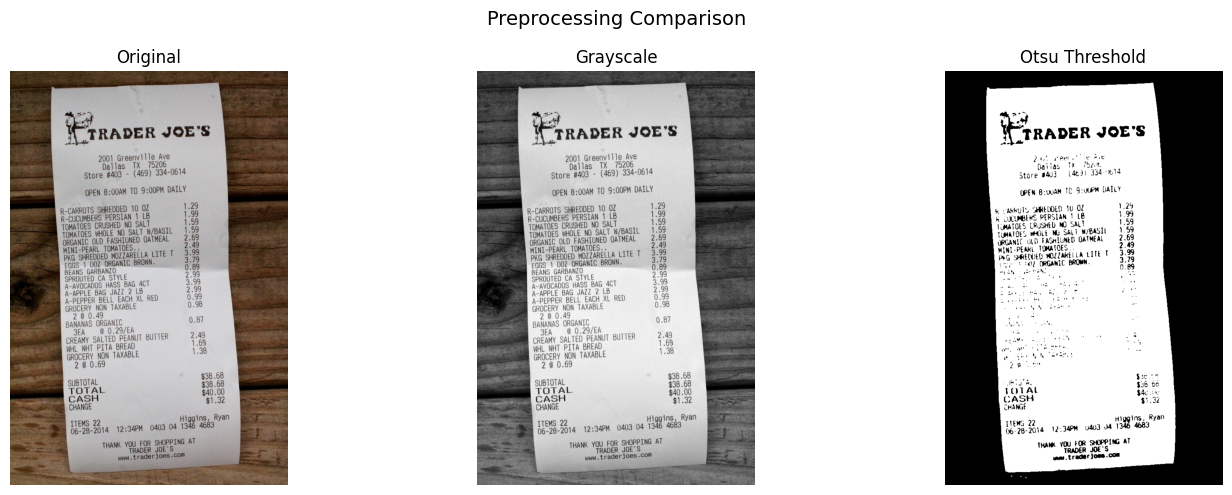


=== OCR Character Count Per Method ===
  Raw         : 835 characters
  Grayscale   : 835 characters
  Otsu        : 556 characters


In [34]:
def compare_preprocessing(image_path, config=r'--oem 3 --psm 6'):
    """
    Load an image and compare OCR output quality across three preprocessing methods.
    Returns a dict with character counts as a proxy for OCR completeness.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not load: {image_path}")
        return None

    methods = {
        "Raw":        img,
        "Grayscale":  preprocess_gray(img),
        "Otsu":       preprocess_otsu(img)
    }

    results = {}
    for name, processed in methods.items():
        text = pytesseract.image_to_string(processed, config=config)
        results[name] = {"text": text, "char_count": len(text.strip())}

    return results

# ── Visualise the three preprocessing outputs side by side ──
def show_preprocessing_comparison(image_path):
    img = cv2.imread(image_path)
    gray  = preprocess_gray(img)
    otsu  = preprocess_otsu(img)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Preprocessing Comparison", fontsize=14)

    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(gray, cmap="gray")
    axes[1].set_title("Grayscale")
    axes[1].axis("off")

    axes[2].imshow(otsu, cmap="gray")
    axes[2].set_title("Otsu Threshold")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

# ── Run on first receipt image ──
show_preprocessing_comparison("data/receipts/1.jpg")

results = compare_preprocessing("data/receipts/1.jpg")
print("\n=== OCR Character Count Per Method ===")
for method, r in results.items():
    print(f"  {method:12s}: {r['char_count']} characters")


## Edge detection
Using the Canny algorithm highlights structural boundaries in the document to isolate the subject and remove any background that could cause noise when reading in the text from the receipt
ref:https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html

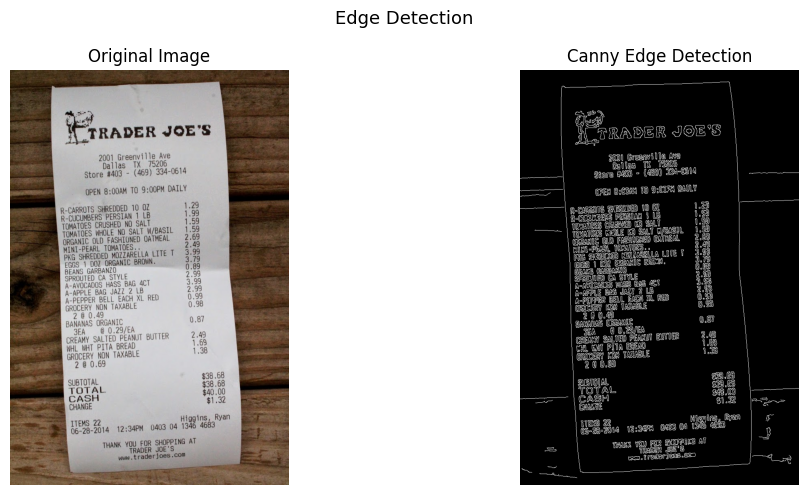

In [35]:
def detect_edges(img):
    """
    Apply Canny edge detection to a document image.
    Threshold values tuned for receipt/document images.
    Reference: https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, threshold1=50, threshold2=150)
    return edges

img = cv2.imread("data/receipts/1.jpg")
edges = detect_edges(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Canny Edge Detection")
axes[1].axis("off")

plt.suptitle("Edge Detection", fontsize=13)
plt.tight_layout()
plt.show()


## Contour Detection Text block and region identification
Countours trace the boundaries of connected regions in an image. On a receipt each contour tupically corresponds to a line of text, allogo or a table cell
ref: https://docs.opencv.org/4.x/d4/d73/tutorial_py_contours_begin.html

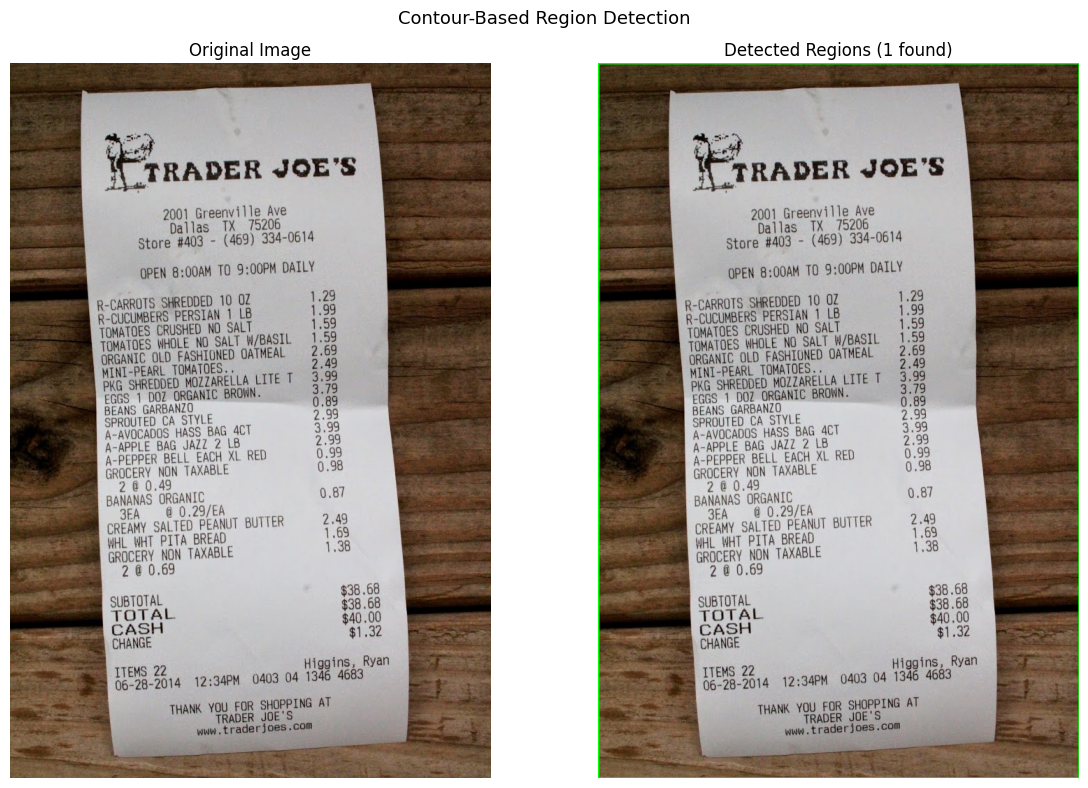

Total regions detected: 1


In [36]:
def detect_contours(img, min_area=500):
    """
    Detect contours in a document image and return bounding rectangles
    for regions larger than min_area pixels.
    Reference: https://docs.opencv.org/4.x/d4/d73/tutorial_py_contours_begin.html
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Dilate to merge nearby text into blocks
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (18, 3))
    dilated = cv2.dilate(thresh, kernel, iterations=1)

    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    regions = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w * h > min_area:
            regions.append((x, y, w, h))

    return regions

img = cv2.imread("data/receipts/1.jpg")
regions = detect_contours(img)

# Draw bounding boxes on a copy
img_annotated = img.copy()
for (x, y, w, h) in regions:
    cv2.rectangle(img_annotated, (x, y), (x+w, y+h), (0, 255, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Detected Regions ({len(regions)} found)")
axes[1].axis("off")

plt.suptitle("Contour-Based Region Detection", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Total regions detected: {len(regions)}")


## Image Segmentation Connected Components
Connected components analysis labels each distinct region of pixels, enabling us to isolate and count indicidual text lines, logos or other elements
ref: https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html

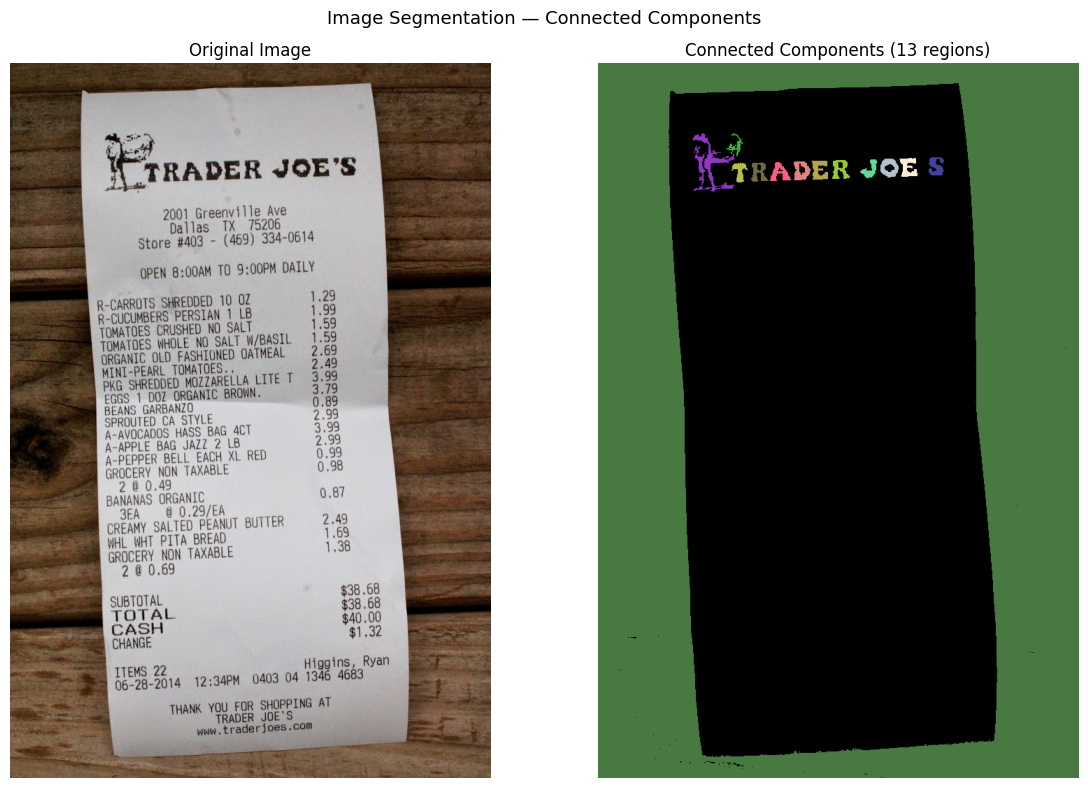

In [37]:
def segment_connected_components(img, min_area=200):
    """
    Use connected components to segment a document into labelled regions.
    Returns a coloured label map for visualisation.
    Reference: https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(thresh, connectivity=8)

    # Build colour map — skip label 0 (background)
    coloured = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
    significant = 0
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area > min_area:
            colour = np.random.randint(50, 255, size=3)
            coloured[labels == i] = colour
            significant += 1

    return coloured, significant

img = cv2.imread("data/receipts/1.jpg")
segmented, count = segment_connected_components(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(segmented)
axes[1].set_title(f"Connected Components ({count} regions)")
axes[1].axis("off")

plt.suptitle("Image Segmentation — Connected Components", fontsize=13)
plt.tight_layout()
plt.show()


# Multi-modal
Combinging the outputs of both NLP and CV pipeline to produce a unified understanding of each document. Detected image regions are matched with COR text extracted from those same regions linking visual structure and text

## Extracting Text Pre Visual Region
Each bounding box detected by contour detection is cropped and passed to Tesseract independently

In [38]:
def extract_text_from_regions(img, regions, config=r'--oem 3 --psm 6'):
    """
    For each detected bounding-box region, crop the image and run OCR.
    Returns a list of dicts with region coordinates and extracted text.
    """
    region_data = []
    for i, (x, y, w, h) in enumerate(regions):
        crop = img[y:y+h, x:x+w]
        text = pytesseract.image_to_string(crop, config=config).strip()
        if text:
            region_data.append({
                "region_id": i,
                "bbox": (x, y, w, h),
                "text": text,
                "char_count": len(text)
            })
    return region_data

img = cv2.imread("data/receipts/1.jpg")
regions = detect_contours(img)
region_data = extract_text_from_regions(img, regions)

print(f"=== Text Extracted from {len(region_data)} Regions ===")
for r in region_data[:6]:  # show first 6 for brevity
    print(f"\nRegion {r['region_id']} | bbox={r['bbox']}")
    print(f"  Text: {r['text'][:100]}")


=== Text Extracted from 1 Regions ===

Region 0 | bbox=(0, 0, 688, 1024)
  Text: = og
( TRADER JOE’S
2001 Greenville Ave
Dallas TX 75206
Store #403 - (469) 334-0614
OPEN 8:00AM TO 9


## Unified Document Analysis
We now combine region level text with NPL analysis (NER, Strucutred field extraction Sentiment) to produce a complete multi modal understanding of the document

In [39]:
def analyse_document(image_path):
    """
    Full multi-modal pipeline for a single document image.
    Combines OCR, NLP, and computer vision outputs into one structured result.
    """
    print(f"\n{'='*60}")
    print(f"Analysing: {image_path}")
    print('='*60)

    # ── Step 1: Load image ──
    img = cv2.imread(image_path)
    if img is None:
        print("ERROR: Could not load image.")
        return None

    # ── Step 2: Image preprocessing ──
    gray_img = preprocess_gray(img)
    print("✓ Image preprocessed")

    # ── Step 3: OCR ──
    config = r'--oem 3 --psm 6'
    raw_text = pytesseract.image_to_string(gray_img, config=config)
    print(f"✓ OCR complete — {len(raw_text.strip())} characters extracted")

    # ── Step 4: NLP ──
    cleaned = clean_text(raw_text)
    tokens  = clean_with_nlp(cleaned)
    fields  = extract_receipt_fields(raw_text, filename=image_path)
    ner     = run_ner(raw_text)
    sent    = analyse_sentiment(raw_text)
    print(f"✓ NLP complete — {len(tokens)} tokens, {len(ner)} entity types found")

    # ── Step 5: Computer vision — contours ──
    regions = detect_contours(img)
    region_data = extract_text_from_regions(img, regions)
    print(f"✓ Vision complete — {len(regions)} regions detected")

    return {
        "image_path":    image_path,
        "ocr_text":      raw_text,
        "tokens":        tokens,
        "fields":        fields,
        "ner":           ner,
        "sentiment":     sent,
        "regions":       region_data,
        "region_count":  len(regions)
    }

# ── Run on a single receipt ──
result = analyse_document("data/receipts/1.jpg")



Analysing: data/receipts/1.jpg
✓ Image preprocessed


✓ OCR complete — 835 characters extracted
✓ NLP complete — 80 tokens, 6 entity types found
✓ Vision complete — 1 regions detected


# Final Output

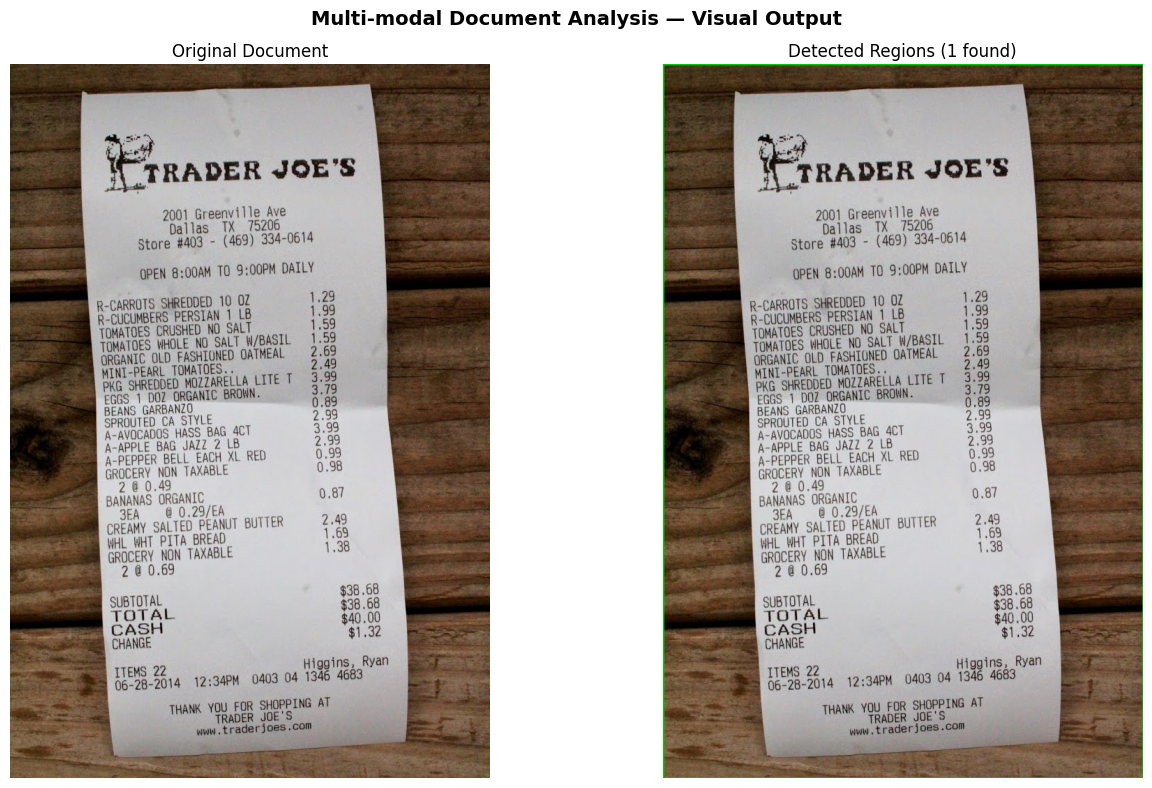


  STRUCTURED DOCUMENT REPORT
  File       : data/receipts/1.jpg
  Merchant   : TRADER JOES
  Date       : 06-28-2014
  Time       : 12:34PM
  Total      : 38.68
  Regions    : 1
  Tokens     : 80

── Named Entities ──
  CARDINAL    : 5, 469, 334
  PERSON      : JOE, Greenville Ave, Ryan
  DATE        : 2001, 06-28-2014, 04 1346 4683
  GPE         : Dallas
  MONEY       : #403 -, 38.68, 38
  ORG         : DAILY, ORGANIC OLD FASHIONED, PKG

── Sentiment ──
  Polarity     : 0.029  (positive)
  Subjectivity : 0.279

── Top NLP Tokens ──
  ['trader', 'joe', 'greenville', 'ave', 'dallas', 'tx', 'store', 'open', 'daily', 'rcarrot', 'shred', 'oz', 'rcucumber', 'persian', 'lb']

── OCR Preview ──
5
( TRADER JOE’S
2001 Greenville Ave
Dallas TX 75206
Store #403 - (469) 334-0614
OPEN 8:00AM TO 9:00PM DAILY
R-CARROTS SHREDDED 10 OZ 1,29
R-CUCUMBERS PERSIAN 1 LB 1.99
TOMATOES CRUSHED NO SALT 1.59
TOMATOES WHOLE NO SALT W/BASIL 1.59
ORGANIC OLD FASHIONED OATMEAL 2.69
MINI-PEARL TOMATOES. . 2.49
PK


In [40]:
def display_final_report(result):
    """
    Display a comprehensive visual and textual report for a processed document.
    """
    if result is None:
        print("No result to display.")
        return

    img_orig = cv2.imread(result["image_path"])
    img_annotated = img_orig.copy()

    # Draw region bounding boxes on the annotated image
    for r in result["regions"]:
        x, y, w, h = r["bbox"]
        cv2.rectangle(img_annotated, (x, y), (x+w, y+h), (0, 200, 0), 2)

    # ── Visual panel ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    axes[0].imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Document", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Detected Regions ({result['region_count']} found)", fontsize=12)
    axes[1].axis("off")

    plt.suptitle("Multi-modal Document Analysis — Visual Output", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # ── Textual report ──
    f = result["fields"]
    print("\n" + "="*60)
    print("  STRUCTURED DOCUMENT REPORT")
    print("="*60)
    print(f"  File       : {result['image_path']}")
    print(f"  Merchant   : {f.get('merchant', 'N/A')}")
    print(f"  Date       : {f.get('date', 'N/A')}")
    print(f"  Time       : {f.get('time', 'N/A')}")
    print(f"  Total      : {f.get('total', 'N/A')}")
    print(f"  Regions    : {result['region_count']}")
    print(f"  Tokens     : {len(result['tokens'])}")

    print("\n── Named Entities ──")
    if result["ner"]:
        for label, vals in result["ner"].items():
            print(f"  {label:12s}: {', '.join(vals[:3])}")
    else:
        print("  None detected")

    print("\n── Sentiment ──")
    s = result["sentiment"]
    print(f"  Polarity     : {s['polarity']}  ({s['assessment']})")
    print(f"  Subjectivity : {s['subjectivity']}")

    print("\n── Top NLP Tokens ──")
    print(f"  {result['tokens'][:15]}")

    print("\n── OCR Preview ──")
    print(result["ocr_text"][:300])
    print("="*60)

display_final_report(result)


## Batch Processing all images
Running a full pipeline across all images in the dataset and printing a summary table

In [ ]:
import os

data_dir = "data/receipts"
image_files = sorted([
    os.path.join(data_dir, f)
    for f in os.listdir(data_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

print(f"Found {len(image_files)} document images.\n")
print(f"{'File':<20} {'Merchant':<25} {'Date':<12} {'Total':<8} {'Regions':<8} {'Tokens'}")
print("-" * 90)

batch_results = []
for path in image_files[:5]:  # Cap at 5 for time removing slice for full run
    r = analyse_document(path)
    if r:
        batch_results.append(r)
        f = r["fields"]
        fname = os.path.basename(path)
        print(f"{fname:<20} {str(f.get('merchant','N/A')):<25} {str(f.get('date','N/A')):<12} "
              f"{str(f.get('total','N/A')):<8} {r['region_count']:<8} {len(r['tokens'])}")

print(f"\nProcessed {len(batch_results)} documents successfully.")


Found 20 document images.

File                 Merchant                  Date         Total    Regions  Tokens
------------------------------------------------------------------------------------------

Analysing: data/receipts/0.jpg
✓ Image preprocessed


✓ OCR complete — 344 characters extracted
✓ NLP complete — 33 tokens, 5 entity types found
✓ Vision complete — 18 regions detected
0.jpg                ALMART                    None         5.11     18       33

Analysing: data/receipts/1.jpg
✓ Image preprocessed
✓ OCR complete — 835 characters extracted
✓ NLP complete — 80 tokens, 6 entity types found
✓ Vision complete — 1 regions detected
1.jpg                TRADER JOES               06-28-2014   38.68    1        80

Analysing: data/receipts/10.jpg
✓ Image preprocessed
✓ OCR complete — 1218 characters extracted
✓ NLP complete — 170 tokens, 10 entity types found
✓ Vision complete — 1 regions detected
10.jpg               ABR Sitar ienltatt gs Mae i None         338.16   1        170

Analysing: data/receipts/11.jpg
✓ Image preprocessed
✓ OCR complete — 562 characters extracted
✓ NLP complete — 64 tokens, 7 entity types found
✓ Vision complete — 42 regions detected
11.jpg               - ree                     None         None    

KeyboardInterrupt: 